In [1]:
# Core
import pandas as pd
import numpy as np
import os
import math
import re
import random
import matplotlib.pyplot as plt

# Splitting
from sklearn.model_selection import train_test_split

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# TF-IDF (Model 1)
from sklearn.feature_extraction.text import TfidfVectorizer

# LSTM (Model 2)
from collections import Counter

# Transformer (Model 3)
import torch.hub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [2]:
data = pd.read_csv("amazon_cells_labelled_LARGE_25K.txt", delimiter='\t', header=None)
data.columns = ['Sentence', 'Class']

# Basic cleaning ONLY (safe for all models)
data['Sentence'] = data['Sentence'].astype(str).str.strip()

texts = data['Sentence'].tolist()
labels = data['Class'].tolist()

In [3]:
# First split: train + temp
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

# Second split: validation + test
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))


Train: 20000
Validation: 2500
Test: 2500


# Task 1.2 - Custom Transformer Implementation


In [4]:
# Prepare custom tokenizer, vocabulary, and data loaders
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2
MAX_SEQ_LEN = 128

def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_texts = [clean_text(text) for text in train_texts]
val_texts = [clean_text(text) for text in val_texts]
test_texts = [clean_text(text) for text in test_texts]

def build_vocab(sentences, min_freq=MIN_FREQ, max_size=MAX_VOCAB_SIZE):
    counter = Counter()
    for sentence in sentences:
        counter.update(sentence.split())
    tokens = [tok for tok, freq in counter.most_common(max_size) if freq >= min_freq]
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for idx, token in enumerate(tokens, start=2):
        vocab[token] = idx
    return vocab

vocab = build_vocab(train_texts)
vocab_size = len(vocab)
pad_idx = vocab[PAD_TOKEN]
unk_idx = vocab[UNK_TOKEN]

print('Vocabulary size:', vocab_size)

def encode_sentence(sentence, vocab, max_len=MAX_SEQ_LEN):
    tokens = sentence.split()
    token_ids = [vocab.get(token, unk_idx) for token in tokens[:max_len]]
    return torch.tensor(token_ids, dtype=torch.long)

class TransformerDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.examples = [encode_sentence(text, vocab) for text in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.examples[idx], self.labels[idx]

def collate_batch(batch):
    input_ids, labels = zip(*batch)
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=pad_idx)
    attention_mask = (input_ids != pad_idx).long()
    labels = torch.stack(labels)
    return input_ids, attention_mask, labels

train_dataset = TransformerDataset(train_texts, train_labels, vocab)
val_dataset = TransformerDataset(val_texts, val_labels, vocab)
test_dataset = TransformerDataset(test_texts, test_labels, vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch)

print('Example batch shapes: ')
for batch in train_loader:
    input_ids, attention_mask, labels = batch
    print('input_ids', input_ids.shape, 'attention_mask', attention_mask.shape, 'labels', labels.shape)
    break


Vocabulary size: 9132
Example batch shapes: 
input_ids torch.Size([32, 27]) attention_mask torch.Size([32, 27]) labels torch.Size([32])


In [5]:
# Define transformer model and positional encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, nhead=8, num_layers=2, ff_dim=512, num_classes=2, dropout=0.1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.position = PositionalEncoding(embed_dim, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, num_classes),
        )

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids) * math.sqrt(self.embedding.embedding_dim)
        x = self.position(x)
        src_key_padding_mask = attention_mask == 0 if attention_mask is not None else None
        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1)
            x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            x = x.mean(dim=1)
        return self.classifier(x)


In [6]:
# Build model, loss, optimizer, and scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    nhead=4,
    num_layers=2,
    ff_dim=512,
    num_classes=2,
    dropout=0.3,
    pad_idx=pad_idx,
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

In [7]:
# Create Dataset + DataLoader
train_dataset = TransformerDataset(train_texts, train_labels, vocab)
val_dataset = TransformerDataset(val_texts, val_labels, vocab)
test_dataset = TransformerDataset(test_texts, test_labels, vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch)


In [8]:
# Device and model setup
print('Using device:', device)
print('Model summary:')
print(model)


Using device: cpu
Model summary:
TransformerClassifier(
  (embedding): Embedding(9132, 64, padding_idx=0)
  (position): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=512, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=512, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=512, bias=True)
    (1): ReLU()
    (2)

In [9]:
#training loop

train_losses = []
val_losses = []

epochs = 100
best_val_loss = float("inf")
best_epoch = 0

#directory to store checkpoints
os.makedirs('checkpoints', exist_ok=True)

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        total_train_loss += loss.item() * input_ids.size(0)
        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            total_val_loss += loss.item() * input_ids.size(0)
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch+1
        torch.save(model.state_dict(), f'checkpoints/best_model_epoch_{epoch+1}.pt')
        print(f'Best model saved at epoch {epoch+1}')


C:\Users\SECHGUR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch 1: Train Loss=0.6613, Val Loss=0.6344
Best model saved at epoch 1
Epoch 2: Train Loss=0.6319, Val Loss=0.5871
Best model saved at epoch 2
Epoch 3: Train Loss=0.6052, Val Loss=0.5607
Best model saved at epoch 3
Epoch 4: Train Loss=0.5828, Val Loss=0.5585
Best model saved at epoch 4
Epoch 5: Train Loss=0.5710, Val Loss=0.5484
Best model saved at epoch 5
Epoch 6: Train Loss=0.5578, Val Loss=0.5342
Best model saved at epoch 6
Epoch 7: Train Loss=0.5469, Val Loss=0.5160
Best model saved at epoch 7
Epoch 8: Train Loss=0.5319, Val Loss=0.5122
Best model saved at epoch 8
Epoch 9: Train Loss=0.5234, Val Loss=0.5102
Best model saved at epoch 9
Epoch 10: Train Loss=0.5190, Val Loss=0.5043
Best model saved at epoch 10
Epoch 11: Train Loss=0.5151, Val Loss=0.5010
Best model saved at epoch 11
Epoch 12: Train Loss=0.5086, Val Loss=0.4980
Best model saved at epoch 12
Epoch 13: Train Loss=0.5015, Val Loss=0.4858
Best model saved at epoch 13
Epoch 14: Train Loss=0.4945, Val Loss=0.4833
Best model 

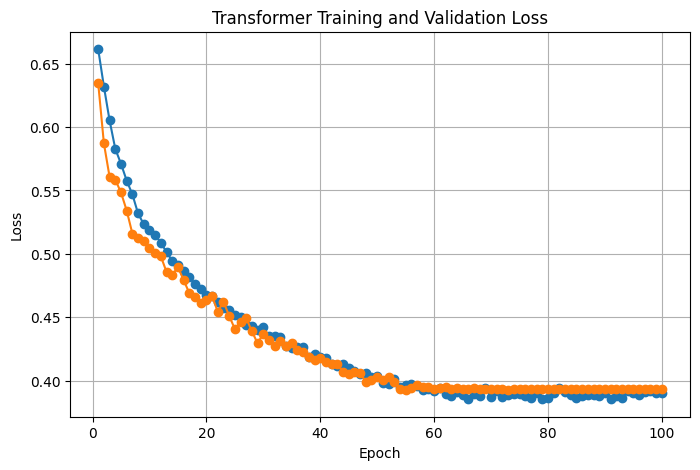

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Training and Validation Loss')
plt.grid(True)
plt.show()

In [14]:
#Validation Evaluation

from sklearn.metrics import accuracy_score, classification_report

model.eval()

val_preds = []
val_true = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(logits, dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_true.extend(labels.cpu().numpy())

print("Validation Accuracy:", accuracy_score(val_true, val_preds))
print(classification_report(val_true, val_preds))


Validation Accuracy: 0.8352
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       988
           1       0.85      0.88      0.87      1512

    accuracy                           0.84      2500
   macro avg       0.83      0.82      0.83      2500
weighted avg       0.83      0.84      0.83      2500



In [15]:
#Test Evaluation (Final Results)

model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(logits, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(test_true, test_preds))
print(classification_report(test_true, test_preds))


Test Accuracy: 0.8372
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       989
           1       0.85      0.88      0.87      1511

    accuracy                           0.84      2500
   macro avg       0.83      0.83      0.83      2500
weighted avg       0.84      0.84      0.84      2500



With a larger dataset, the transformer model demonstrates stable convergence and improved generalization. However, overfitting still occurs after a few epochs, indicating that even with more data, careful regularization and early stopping remain important.